In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# URL for the dataset
url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv"

# Load the data
try:
    df = pd.read_csv(url)
except:
    # Fallback if URL is unreachable in your environment
    df = pd.read_csv('netflix.csv')

# Basic Inspection
print("Dataset Shape:", df.shape)
print("\nColumn Information:")
df.info()

# Checking for Missing Values
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of Missing Values:\n", missing_percent)

Dataset Shape: (8807, 12)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Percentage of Missing Values:
 show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       

In [ ]:
# Handle Missing Values
df['director'] = df['director'].fillna('Unknown Director')
df['cast'] = df['cast'].fillna('Unknown Cast')
df['country'] = df['country'].fillna('Unknown Country')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0]) # Impute with mode

# Drop rows with missing date_added or duration (usually very few)
df.dropna(subset=['date_added', 'duration'], inplace=True)

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

In [ ]:
# Function to unnest comma-separated columns
def unnest_column(dataframe, column):
    # Split the strings into lists and explode
    new_df = dataframe.copy()
    new_df[column] = new_df[column].str.split(', ')
    return new_df.explode(column)

# Example: Unnesting by Cast and Country
df_cast = unnest_column(df, 'cast')
df_genre = unnest_column(df, 'listed_in')
df_country = unnest_column(df, 'country')

print(f"Total Unique Actors: {df_cast['cast'].nunique()}")
print(f"Total Unique Genres: {df_genre['listed_in'].nunique()}")

Total Unique Actors: 36404
Total Unique Genres: 42


/tmp/ipykernel_356/2163224068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Reds')
/tmp/ipykernel_356/2163224068.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='viridis')
/tmp/ipykernel_356/2163224068.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='magma')


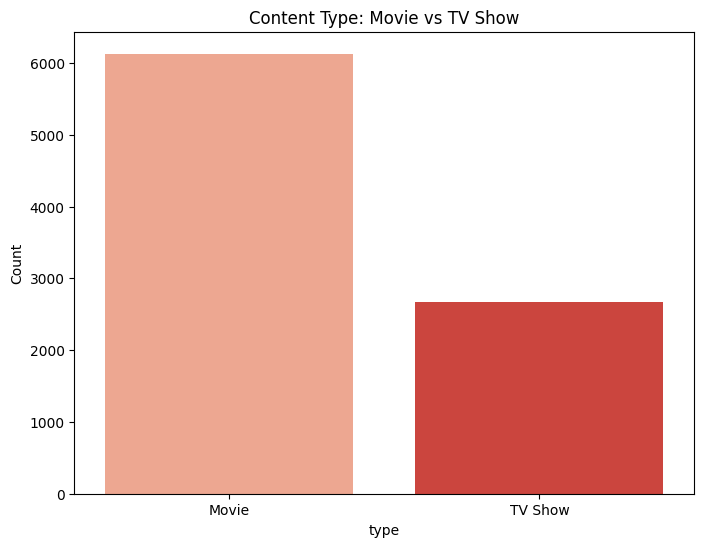

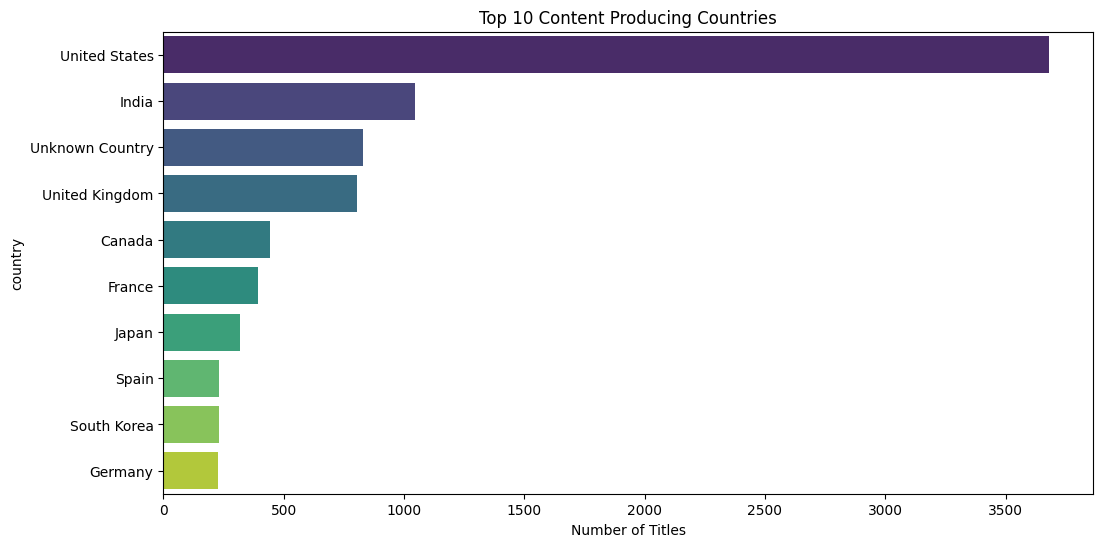

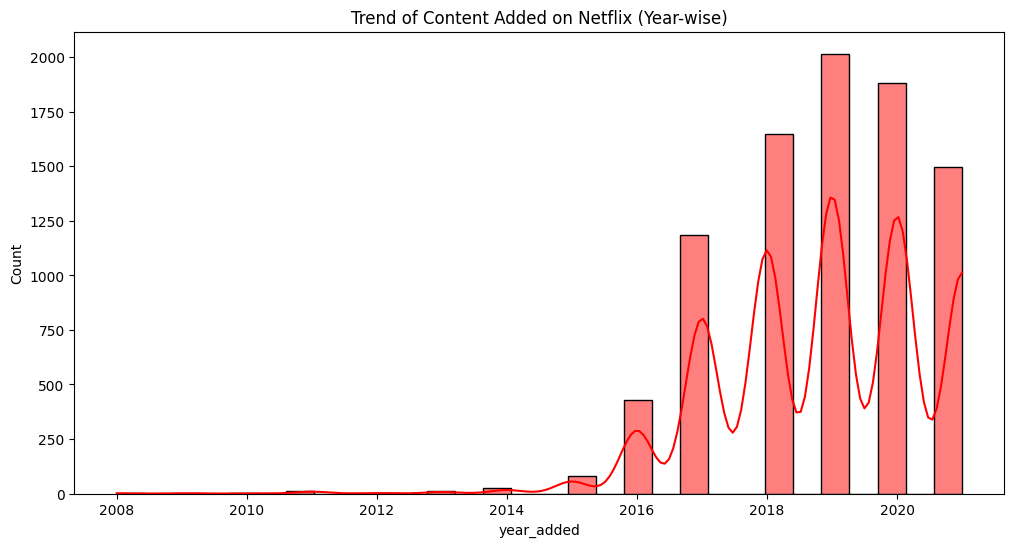

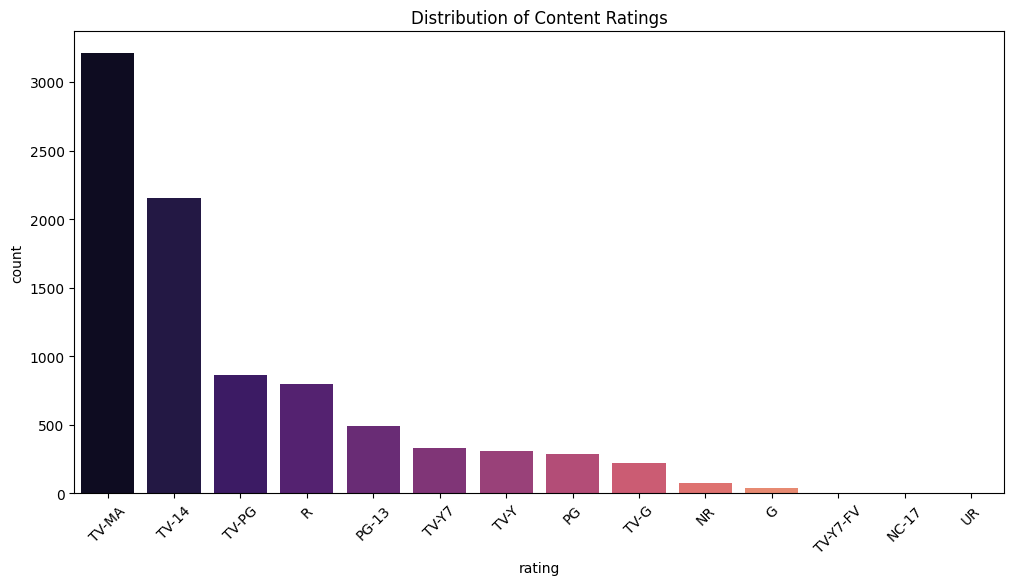

In [ ]:
# I. Distribution of Movie vs TV Show
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=df, palette='Reds')
plt.title('Content Type: Movie vs TV Show')
plt.ylabel('Count')
plt.savefig('type_distribution.png')

# II. Top 10 Countries producing Content
top_10_countries = df_country['country'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='viridis')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Number of Titles')
plt.savefig('top_countries.png')

# III. Content Added Trend Over Years
plt.figure(figsize=(12, 6))
sns.histplot(df['year_added'], bins=30, kde=True, color='red')
plt.title('Trend of Content Added on Netflix (Year-wise)')
plt.savefig('addition_trend.png')

# IV. Rating Distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='magma')
plt.xticks(rotation=45)
plt.title('Distribution of Content Ratings')
plt.savefig('rating_dist.png')

In [ ]:
df_cast['cast'].value_counts().head(10)

,count
cast,
Unknown Cast,825
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Akshay Kumar,30
Om Puri,30


In [ ]:
df_country['country'].value_counts().head(10)

,count
country,
United States,3680
India,1046
Unknown Country,830
United Kingdom,803
Canada,445
France,393
Japan,317
Spain,232
South Korea,231


In [ ]:
df['date_added'].dt.year.value_counts().sort_index()

,count
date_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,427


<Axes: xlabel='release_year', ylabel='Count'>

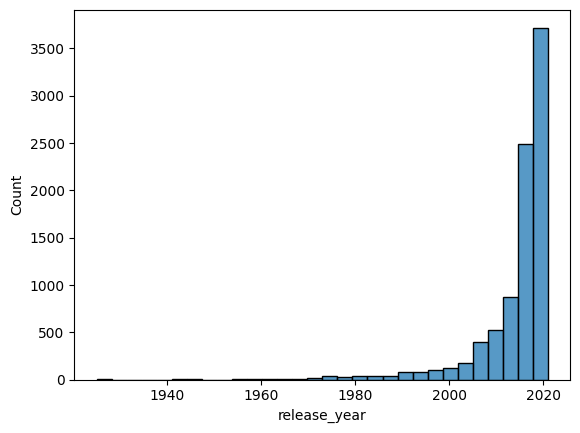

In [ ]:
sns.histplot(df['release_year'], bins=30)

In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,3209
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


In [ ]:
df_genre['listed_in'].value_counts().head(5)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1350
Documentaries,869


In [ ]:
df['description'].str.len().mean()

np.float64(143.3025926768251)